<div style="background-color:#F8F9FA; border:2px solid #343A40; padding:14px; border-radius:8px; margin-top:22px; margin-bottom:18px;">

<h2 style="color:#343A40; font-family:'Segoe UI', Arial, sans-serif; text-align:center;">
Présentation du dataset
</h2>

</div>

<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Source et contexte des données
</p>

Le jeu de données utilisé dans ce projet est le **Student Depression Dataset**, disponible sur la plateforme Kaggle à l’adresse suivante : [Student Depression Dataset – Kaggle](https://www.kaggle.com/datasets/hopesb/student-depression-dataset).

Il s’agit d’un dataset tabulaire au format CSV portant sur la santé mentale des étudiants, avec un intérêt particulier pour l’étude de la dépression et des facteurs pouvant y être associés.

Chaque ligne du dataset correspond à un étudiant, tandis que chaque colonne représente une caractéristique individuelle, académique, comportementale ou psychologique. Le jeu de données regroupe notamment des informations relatives au profil sociodémographique des étudiants, à leur environnement académique, à leurs habitudes de vie, ainsi qu’à certains indicateurs liés au bien-être mental.

Ce dataset est particulièrement adapté à notre projet, car il permet d’étudier les relations possibles entre la dépression étudiante et plusieurs facteurs explicatifs tels que la pression académique, la satisfaction dans les études, la durée du sommeil, les habitudes alimentaires, le stress financier ou encore les antécédents familiaux liés à la santé mentale. Il offre ainsi une base pertinente pour mener une analyse exploratoire des données, produire des visualisations interprétables et construire éventuellement des analyses statistiques ou économétriques.

Dans le cadre de ce projet, la variable liée à la dépression constitue la variable d’intérêt principale. Les autres variables seront mobilisées comme variables explicatives ou variables de segmentation afin d’identifier les profils d’étudiants les plus exposés au risque de dépression.

Il convient toutefois de souligner que ce dataset porte sur un sujet sensible : la santé mentale. Les résultats obtenus devront donc être interprétés avec prudence. L’objectif de l’analyse n’est pas d’établir un diagnostic médical, mais d’identifier des tendances statistiques et des associations entre variables. Toute conclusion devra rester limitée au périmètre du dataset et être formulée dans une perspective analytique, préventive et non clinique.

<br>
<br>
 
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Importation des bibliothèques
</p>

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Amélioration de l'affichage des tableaux
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

<br>
<br>

<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Chargement du fichier de données
</p>

In [73]:
df = pd.read_csv("student_depression_raw.csv")

df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.00,Visakhapatnam,Student,5.00,0.00,8.97,2.00,0.00,5-6 hours,Healthy,B.Pharm,Yes,3.00,1.00,No,1
1,8,Female,24.00,Bangalore,Student,2.00,0.00,5.90,5.00,0.00,5-6 hours,Moderate,BSc,No,3.00,2.00,Yes,0
2,26,Male,31.00,Srinagar,Student,3.00,0.00,7.03,5.00,0.00,Less than 5 hours,Healthy,BA,No,9.00,1.00,Yes,0
3,30,Female,28.00,Varanasi,Student,3.00,0.00,5.59,2.00,0.00,7-8 hours,Moderate,BCA,Yes,4.00,5.00,Yes,1
4,32,Female,25.00,Jaipur,Student,4.00,0.00,8.13,3.00,0.00,5-6 hours,Moderate,M.Tech,Yes,1.00,1.00,No,0


<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Dimension des données
</p>

In [74]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 27901
Nombre de colonnes : 18


<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Informations générales
</p>

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Affichage des noms de variables
</p>

In [76]:
pd.DataFrame({
    "Variable": df.columns
})

,Variable
0,id
1,Gender
2,Age
3,City
4,Profession
5,Academic Pressure
6,Work Pressure
7,CGPA
8,Study Satisfaction
9,Job Satisfaction


<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Affichage des noms de modalités
</p>

In [77]:
variables_qualitatives = df.select_dtypes(include='object').columns

for colonne in variables_qualitatives:
    print("\n" + "="*100)
    print("Variable :", colonne)
    print("Nombre de modalités :", df[colonne].nunique(dropna=False))
    print("Modalités :")
    
    for modalite in df[colonne].dropna().unique():
        print("-", modalite)


Variable : Gender
Nombre de modalités : 2
Modalités :
- Male
- Female

Variable : City
Nombre de modalités : 52
Modalités :
- Visakhapatnam
- Bangalore
- Srinagar
- Varanasi
- Jaipur
- Pune
- Thane
- Chennai
- Nagpur
- Nashik
- Vadodara
- Kalyan
- Rajkot
- Ahmedabad
- Kolkata
- Mumbai
- Lucknow
- Indore
- Surat
- Ludhiana
- Bhopal
- Meerut
- Agra
- Ghaziabad
- Hyderabad
- Vasai-Virar
- Kanpur
- Patna
- Faridabad
- Delhi
- Saanvi
- M.Tech
- Bhavna
- Less Delhi
- City
- 3.0
- Less than 5 Kalyan
- Mira
- Harsha
- Vaanya
- Gaurav
- Harsh
- Reyansh
- Kibara
- Rashi
- ME
- M.Com
- Nalyan
- Mihir
- Nalini
- Nandini
- Khaziabad

Variable : Profession
Nombre de modalités : 14
Modalités :
- Student
- Civil Engineer
- Architect
- UX/UI Designer
- Digital Marketer
- Content Writer
- Educational Consultant
- Teacher
- Manager
- Chef
- Doctor
- Lawyer
- Entrepreneur
- Pharmacist

Variable : Sleep Duration
Nombre de modalités : 5
Modalités :
- 5-6 hours
- Less than 5 hours
- 7-8 hours
- More than 8 

<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Renommage des colonnes en français
</p>

In [78]:
df = df.rename(columns={
    'id': 'id',
    'Gender': 'sexe',
    'Age': 'age',
    'City': 'ville',
    'Profession': 'profession',
    'Academic Pressure': 'pression_academique',
    'Work Pressure': 'pression_travail',
    'CGPA': 'moyenne_academique',
    'Study Satisfaction': 'satisfaction_etudes',
    'Job Satisfaction': 'satisfaction_travail',
    'Sleep Duration': 'duree_sommeil',
    'Dietary Habits': 'habitudes_alimentaires',
    'Degree': 'diplome',
    'Have you ever had suicidal thoughts ?': 'pensees_suicidaires',
    'Work/Study Hours': 'heures_travail_etudes',
    'Financial Stress': 'stress_financier',
    'Family History of Mental Illness': 'antecedents_familiaux_maladie_mentale',
    'Depression': 'depression'
})

<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Renommage des modalités en français
</p>

In [79]:
df= df.replace({
    "sexe": {
        "Male": "Homme",
        "Female": "Femme"
    },
    
    "duree_sommeil": {
        "Less than 5 hours": "Moins de 5 heures",
        "5-6 hours": "5-6 heures",
        "7-8 hours": "7-8 heures",
        "More than 8 hours": "Plus de 8 heures",
        "Others": "Autres"
    },
    
    "habitudes_alimentaires": {
        "Healthy": "Saine",
        "Moderate": "Modérée",
        "Unhealthy": "Malsaine",
        "Others": "Autres"
    },
    
    "pensees_suicidaires": {
        "Yes": "Oui",
        "No": "Non"
    },
    
    "antecedents_familiaux_maladie_mentale": {
        "Yes": "Oui",
        "No": "Non"
    },
    
    "profession": {
        "Student": "Etudiant",
        "Architect": "Architecte",
        "Teacher": "Enseignant",
        "Digital Marketer": "Specialiste en marketing digital",
        "Chef": "Cuisinier",
        "Content Writer": "Redacteur de contenu",
        "Pharmacist": "Pharmacien",
        "Doctor": "Medecin",
        "UX/UI Designer": "Designer UX/UI",
        "Civil Engineer": "Ingenieur civil",
        "Manager": "Manager",
        "Educational Consultant": "Conseiller pedagogique",
        "Lawyer": "Avocat",
        "Entrepreneur": "Entrepreneur"
    },
    
    "diplome": {
        "Class 12": "Classe 12",
        "B.Ed": "Licence en education",
        "B.Com": "Licence en commerce",
        "B.Arch": "Licence en architecture",
        "BCA": "Licence en informatique",
        "MSc": "Master en sciences",
        "B.Tech": "Licence en technologie",
        "MCA": "Master en informatique",
        "M.Tech": "Master en technologie",
        "BHM": "Licence en gestion hoteliere",
        "BSc": "Licence en sciences",
        "M.Ed": "Master en education",
        "B.Pharm": "Licence en pharmacie",
        "M.Com": "Master en commerce",
        "BBA": "Licence en administration des affaires",
        "MBBS": "Medecine",
        "LLB": "Licence en droit",
        "BE": "Licence en ingenierie",
        "BA": "Licence en arts",
        "M.Pharm": "Master en pharmacie",
        "MD": "Doctorat en medecine",
        "MBA": "Master en administration des affaires",
        "MA": "Master en arts",
        "PhD": "Doctorat",
        "LLM": "Master en droit",
        "MHM": "Master en gestion hoteliere",
        "ME": "Master en ingenierie",
        "Others": "Autres"
    }
})

<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Aperçu des cinq premières\dernières lignes suite à la traduction des noms de variables et de modalités
</p>

In [80]:
df.head()

,id,sexe,age,ville,profession,pression_academique,pression_travail,moyenne_academique,satisfaction_etudes,satisfaction_travail,duree_sommeil,habitudes_alimentaires,diplome,pensees_suicidaires,heures_travail_etudes,stress_financier,antecedents_familiaux_maladie_mentale,depression
0,2,Homme,33.00,Visakhapatnam,Etudiant,5.00,0.00,8.97,2.00,0.00,5-6 heures,Saine,Licence en pharmacie,Oui,3.00,1.00,Non,1
1,8,Femme,24.00,Bangalore,Etudiant,2.00,0.00,5.90,5.00,0.00,5-6 heures,Modérée,Licence en sciences,Non,3.00,2.00,Oui,0
2,26,Homme,31.00,Srinagar,Etudiant,3.00,0.00,7.03,5.00,0.00,Moins de 5 heures,Saine,Licence en arts,Non,9.00,1.00,Oui,0
3,30,Femme,28.00,Varanasi,Etudiant,3.00,0.00,5.59,2.00,0.00,7-8 heures,Modérée,Licence en informatique,Oui,4.00,5.00,Oui,1
4,32,Femme,25.00,Jaipur,Etudiant,4.00,0.00,8.13,3.00,0.00,5-6 heures,Modérée,Master en technologie,Oui,1.00,1.00,Non,0


<br>
<br>

In [81]:
df.tail()

,id,sexe,age,ville,profession,pression_academique,pression_travail,moyenne_academique,satisfaction_etudes,satisfaction_travail,duree_sommeil,habitudes_alimentaires,diplome,pensees_suicidaires,heures_travail_etudes,stress_financier,antecedents_familiaux_maladie_mentale,depression
27896,140685,Femme,27.00,Surat,Etudiant,5.00,0.00,5.75,5.00,0.00,5-6 heures,Malsaine,Classe 12,Oui,7.00,1.00,Oui,0
27897,140686,Homme,27.00,Ludhiana,Etudiant,2.00,0.00,9.40,3.00,0.00,Moins de 5 heures,Saine,Master en sciences,Non,0.00,3.00,Oui,0
27898,140689,Homme,31.00,Faridabad,Etudiant,3.00,0.00,6.61,4.00,0.00,5-6 heures,Malsaine,Doctorat en medecine,Non,12.00,2.00,Non,0
27899,140690,Femme,18.00,Ludhiana,Etudiant,5.00,0.00,6.88,2.00,0.00,Moins de 5 heures,Saine,Classe 12,Oui,10.00,5.00,Non,1
27900,140699,Homme,27.00,Patna,Etudiant,4.00,0.00,9.24,1.00,0.00,Moins de 5 heures,Saine,Licence en informatique,Oui,2.00,3.00,Oui,1


<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Affichage de quelques lignes au hasard
</p>

In [82]:
df.sample(10, random_state=42)

,id,sexe,age,ville,profession,pression_academique,pression_travail,moyenne_academique,satisfaction_etudes,satisfaction_travail,duree_sommeil,habitudes_alimentaires,diplome,pensees_suicidaires,heures_travail_etudes,stress_financier,antecedents_familiaux_maladie_mentale,depression
19981,101205,Femme,29.00,Kalyan,Etudiant,2.00,0.00,8.53,3.00,0.00,Plus de 8 heures,Saine,Licence en architecture,Non,10.00,5.00,Non,0
16551,83727,Homme,28.00,Srinagar,Etudiant,2.00,0.00,5.57,5.00,0.00,7-8 heures,Malsaine,Master en technologie,Oui,3.00,1.00,Oui,0
7640,38395,Homme,34.00,Varanasi,Etudiant,3.00,0.00,5.12,4.00,0.00,Plus de 8 heures,Modérée,Master en pharmacie,Oui,4.00,3.00,Oui,0
21266,107434,Homme,21.00,Mumbai,Etudiant,5.00,0.00,8.95,2.00,0.00,Moins de 5 heures,Malsaine,Licence en pharmacie,Oui,8.00,1.00,Non,1
15759,79662,Homme,25.00,Visakhapatnam,Etudiant,5.00,0.00,7.87,2.00,0.00,Moins de 5 heures,Saine,Licence en education,Non,0.00,3.00,Non,1
27146,136821,Homme,24.00,Nagpur,Etudiant,3.00,0.00,6.89,1.00,0.00,5-6 heures,Malsaine,Licence en commerce,Oui,6.00,1.00,Oui,1
24868,125270,Homme,18.00,Vasai-Virar,Etudiant,5.00,0.00,9.88,5.00,0.00,5-6 heures,Modérée,Classe 12,Oui,10.00,2.00,Oui,1
26237,132248,Femme,24.00,Vasai-Virar,Etudiant,2.00,0.00,7.08,2.00,0.00,Moins de 5 heures,Saine,Licence en architecture,Oui,12.00,1.00,Oui,1
7260,36533,Homme,20.00,Surat,Etudiant,4.00,0.00,6.38,2.00,0.00,5-6 heures,Modérée,Classe 12,Non,0.00,2.00,Oui,0
19527,98935,Homme,32.00,Hyderabad,Etudiant,5.00,0.00,7.10,1.00,0.00,Moins de 5 heures,Malsaine,Master en informatique,Oui,12.00,5.00,Oui,1


<br>
<br>
<div style="background-color:#F8F9FA; border:2px solid #343A40; padding:14px; border-radius:8px; margin-top:22px; margin-bottom:18px;">

<h2 style="color:#343A40; font-family:'Segoe UI', Arial, sans-serif; text-align:center;">
Analyse des données
</h2>

</div>

<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Vérification de la structure des données
</p>

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   sexe                                   27901 non-null  object 
 2   age                                    27901 non-null  float64
 3   ville                                  27901 non-null  object 
 4   profession                             27901 non-null  object 
 5   pression_academique                    27901 non-null  float64
 6   pression_travail                       27901 non-null  float64
 7   moyenne_academique                     27901 non-null  float64
 8   satisfaction_etudes                    27901 non-null  float64
 9   satisfaction_travail                   27901 non-null  float64
 10  duree_sommeil                          27901 non-null  object 
 11  ha

<br>
<br>

In [84]:
types_variables = pd.DataFrame({
    "Type détecté": df.dtypes.astype(str),
    "Valeurs non nulles": df.notna().sum().values,
    "Valeurs manquantes": df.isna().sum().values,
    "Nombre de valeurs uniques": df.nunique().values
})

types_variables

,Type détecté,Valeurs non nulles,Valeurs manquantes,Nombre de valeurs uniques
id,int64,27901,0,27901
sexe,object,27901,0,2
age,float64,27901,0,34
ville,object,27901,0,52
profession,object,27901,0,14
pression_academique,float64,27901,0,6
pression_travail,float64,27901,0,3
moyenne_academique,float64,27901,0,332
satisfaction_etudes,float64,27901,0,6
satisfaction_travail,float64,27901,0,5


<br>
<br>

In [85]:
# Conversion des types de variables

# Variables entières :
variables_int = [
    "id",
    "age",
    "pression_academique",
    "pression_travail",
    "satisfaction_etudes",
    "satisfaction_travail",
    "heures_travail_etudes"
]

for col in variables_int:
    df[col] = df[col].astype("int64")


# Variable entière avec valeurs manquantes :
df["stress_financier"] = df["stress_financier"].astype("Int64")


# Variable quantitative continue :
df["moyenne_academique"] = df["moyenne_academique"].astype("float64")


# Variables catégorielles :
variables_category = [
    "sexe",
    "ville",
    "profession",
    "duree_sommeil",
    "habitudes_alimentaires",
    "diplome",
    "pensees_suicidaires",
    "antecedents_familiaux_maladie_mentale"
]

for col in variables_category:
    df[col] = df[col].astype("category")


# Transformation de la variable depression en variable catégorielle lisible :
df["depression"] = df["depression"].map({
    0: "Non",
    1: "Oui"
}).astype("category")

<div style="background-color:#F2F6F8; border-left:5px solid #1E3A5F; padding:12px; border-radius:6px;">

<strong style="color:#1E3A5F;">Commentaire :</strong>

<p style="color:#4A4A4A; font-family:'Segoe UI', Arial, sans-serif;">
Cette étape permet d’adapter le type de chaque variable afin de faciliter l’analyse statistique et la visualisation des données.

Les variables numériques discrètes sont converties en entiers, tandis que la variable "moyenne_academique" est convertie en décimal, car elle peut contenir des valeurs avec virgule.

La variable "stress_financier" est convertie en type Int64, car elle peut contenir des valeurs manquantes tout en restant une variable numérique.

Les variables qualitatives, comme "sexe", "ville", "profession" ou "diplôme", sont transformées en variables catégorielles afin d’améliorer la lisibilité et l’efficacité des analyses.

Enfin, la variable "depression" est recodée en deux modalités claires : Non et Oui, ce qui rend les résultats plus faciles à interpréter dans les graphiques.
</p>

</div>

<br>
<br>

In [86]:
# Synthèse des types de variables après conversion :
types_variables = pd.DataFrame({
    "Variable": df.columns,
    "Type": df.dtypes.astype(str).values,
    "Valeurs non nulles": df.notna().sum().values,
    "Valeurs manquantes": df.isna().sum().values,
    "Nombre de valeurs uniques": df.nunique(dropna=True).values
})

types_variables

,Variable,Type,Valeurs non nulles,Valeurs manquantes,Nombre de valeurs uniques
0,id,int64,27901,0,27901
1,sexe,category,27901,0,2
2,age,int64,27901,0,34
3,ville,category,27901,0,52
4,profession,category,27901,0,14
5,pression_academique,int64,27901,0,6
6,pression_travail,int64,27901,0,3
7,moyenne_academique,float64,27901,0,332
8,satisfaction_etudes,int64,27901,0,6
9,satisfaction_travail,int64,27901,0,5


<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Vérification des valeurs manquantes
</p>

In [87]:
valeurs_manquantes = df.isna().sum().sort_values(ascending=False)

valeurs_manquantes

stress_financier                         3
id                                       0
sexe                                     0
antecedents_familiaux_maladie_mentale    0
heures_travail_etudes                    0
pensees_suicidaires                      0
diplome                                  0
habitudes_alimentaires                   0
duree_sommeil                            0
satisfaction_travail                     0
satisfaction_etudes                      0
moyenne_academique                       0
pression_travail                         0
pression_academique                      0
profession                               0
ville                                    0
age                                      0
depression                               0
dtype: int64

<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Tableau des valeurs manquantes avec pourcentage
</p>

In [88]:
tableau_valeurs_manquantes = pd.DataFrame({
    'Valeurs manquantes': df.isna().sum(),
    'Pourcentage des valeurs manquantes': df.isna().mean() * 100
})

tableau_valeurs_manquantes = tableau_valeurs_manquantes.sort_values(
    by='Valeurs manquantes',
    ascending=False
)

tableau_valeurs_manquantes

,Valeurs manquantes,Pourcentage des valeurs manquantes
stress_financier,3,0.01
id,0,0.00
sexe,0,0.00
antecedents_familiaux_maladie_mentale,0,0.00
heures_travail_etudes,0,0.00
pensees_suicidaires,0,0.00
diplome,0,0.00
habitudes_alimentaires,0,0.00
duree_sommeil,0,0.00
satisfaction_travail,0,0.00


<br>
<br>

In [89]:
# Calcul de la médiane de la variable "stress_financier" :
mediane_stress_financier = df["stress_financier"].median()

# Remplacement des valeurs manquantes par la médiane :
df["stress_financier"] = df["stress_financier"].fillna(mediane_stress_financier)

<div style="background-color:#F2F6F8; border-left:5px solid #1E3A5F; padding:12px; border-radius:6px;">

<strong style="color:#1E3A5F;">Commentaire :</strong>

<p style="color:#4A4A4A; font-family:'Segoe UI', Arial, sans-serif;">
Les valeurs manquantes de la variable "stress_financier" sont remplacées par la médiane de cette même variable.

Ce choix est pertinent, car la médiane est moins sensible aux valeurs extrêmes que la moyenne. Elle permet donc de conserver une distribution plus stable et d’éviter de biaiser l’analyse.

Cette étape assure une meilleure qualité des données avant les analyses statistiques et les visualisations.
</p>

</div>

<br>
<br>

In [90]:
# Vérification :
df.isna().sum().sum()

np.int64(0)

<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Vérification des doublons
</p>

In [91]:
nombre_doublons = df.duplicated().sum()

print("Nombre de doublons complets :", nombre_doublons)

Nombre de doublons complets : 0


<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Valeurs uniques
</p>

In [92]:
df.nunique().sort_values()

depression                                   2
sexe                                         2
pensees_suicidaires                          2
antecedents_familiaux_maladie_mentale        2
pression_travail                             3
habitudes_alimentaires                       4
stress_financier                             5
duree_sommeil                                5
satisfaction_travail                         5
satisfaction_etudes                          6
pression_academique                          6
heures_travail_etudes                       13
profession                                  14
diplome                                     28
age                                         34
ville                                       52
moyenne_academique                         332
id                                       27901
dtype: int64

<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Résumé statistique des variables
</p>

In [93]:
df.describe(include="all")

,id,sexe,age,ville,profession,pression_academique,pression_travail,moyenne_academique,satisfaction_etudes,satisfaction_travail,duree_sommeil,habitudes_alimentaires,diplome,pensees_suicidaires,heures_travail_etudes,stress_financier,antecedents_familiaux_maladie_mentale,depression
count,27901.00,27901,27901.00,27901,27901,27901.00,27901.00,27901.00,27901.00,27901.00,27901,27901,27901,27901,27901.00,27901.00,27901,27901
unique,NaN,2,NaN,52,14,NaN,NaN,NaN,NaN,NaN,5,4,28,2,NaN,<NA>,2,2
top,NaN,Homme,NaN,Kalyan,Etudiant,NaN,NaN,NaN,NaN,NaN,Moins de 5 heures,Malsaine,Classe 12,Oui,NaN,<NA>,Non,Oui
freq,NaN,15547,NaN,1570,27870,NaN,NaN,NaN,NaN,NaN,8310,10317,6080,17656,NaN,<NA>,14398,16336
mean,70442.15,NaN,25.82,NaN,NaN,3.14,0.00,7.66,2.94,0.00,NaN,NaN,NaN,NaN,7.16,3.14,NaN,NaN
std,40641.18,NaN,4.91,NaN,NaN,1.38,0.04,1.47,1.36,0.04,NaN,NaN,NaN,NaN,3.71,1.44,NaN,NaN
min,2.00,NaN,18.00,NaN,NaN,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,0.00,1.00,NaN,NaN
25%,35039.00,NaN,21.00,NaN,NaN,2.00,0.00,6.29,2.00,0.00,NaN,NaN,NaN,NaN,4.00,2.00,NaN,NaN
50%,70684.00,NaN,25.00,NaN,NaN,3.00,0.00,7.77,3.00,0.00,NaN,NaN,NaN,NaN,8.00,3.00,NaN,NaN
75%,105818.00,NaN,30.00,NaN,NaN,4.00,0.00,8.92,4.00,0.00,NaN,NaN,NaN,NaN,10.00,4.00,NaN,NaN


<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Distribution de la variable "profession"
</p>

In [94]:
effectifs_profession = df['profession'].value_counts(dropna=False)
pourcentages_profession = df['profession'].value_counts(normalize=True, dropna=False) * 100

tableau_profession = pd.DataFrame({
    'Effectif': effectifs_profession,
    'Pourcentage': pourcentages_profession
})

tableau_profession

,Effectif,Pourcentage
profession,,
Etudiant,27870,99.89
Architecte,8,0.03
Enseignant,6,0.02
Specialiste en marketing digital,3,0.01
Cuisinier,2,0.01
Medecin,2,0.01
Pharmacien,2,0.01
Redacteur de contenu,2,0.01
Avocat,1,0.00


<br>
<br>

In [95]:
nombre_total = len(df)

nombre_etudiants = (df['profession'] == 'Etudiant').sum()
nombre_non_etudiants = (df['profession'] != 'Etudiant').sum()

print("=== Répartition entre étudiants et non-étudiants ===\n")

print("Nombre total de personnes :", nombre_total)
print("Nombre d'étudiants :", nombre_etudiants)
print("Nombre de non-étudiants :", nombre_non_etudiants)

print("\nPourcentages :")
print("Pourcentage d'étudiants :", round(nombre_etudiants / nombre_total * 100, 2), "%")
print("Pourcentage de non-étudiants :", round(nombre_non_etudiants / nombre_total * 100, 2), "%")

=== Répartition entre étudiants et non-étudiants ===

Nombre total de personnes : 27901
Nombre d'étudiants : 27870
Nombre de non-étudiants : 31

Pourcentages :
Pourcentage d'étudiants : 99.89 %
Pourcentage de non-étudiants : 0.11 %


<br>
<br>

In [96]:
df = df[df["profession"] == "Etudiant"].copy()

# Réinitialisation de l'index après la suppression des lignes :
df = df.reset_index(drop=True)

# Vérification du résultat :
df["profession"].value_counts()

profession
Etudiant                            27870
Architecte                              0
Avocat                                  0
Conseiller pedagogique                  0
Cuisinier                               0
Designer UX/UI                          0
Enseignant                              0
Entrepreneur                            0
Ingenieur civil                         0
Manager                                 0
Medecin                                 0
Pharmacien                              0
Redacteur de contenu                    0
Specialiste en marketing digital        0
Name: count, dtype: int64

<div style="background-color:#F2F6F8; border-left:5px solid #1E3A5F; padding:12px; border-radius:6px;">

<strong style="color:#1E3A5F;">Commentaire :</strong>

<p style="color:#4A4A4A; font-family:'Segoe UI', Arial, sans-serif;">
Cette étape permet d’étudier la répartition des personnes selon leur profession, en calculant à la fois les effectifs et les pourcentages.

Les résultats montrent que la très grande majorité des personnes du dataset sont des étudiants, avec 27 870 individus, soit environ 99,89 % de l’échantillon.

Les autres professions sont très faiblement représentées. Elles ne concernent que 31 personnes au total, soit environ 0,11 % du dataset.

Cette forte domination de la modalité "Etudiant" dans la variable "profession" indique que le jeu de données est principalement centré sur une population étudiante. Les analyses suivantes devront donc être interprétées en tenant compte de ce déséquilibre important entre étudiants et non-étudiants.
</p>

</div>

<br>
<br>

In [97]:
colonnes_a_supprimer = [
    "pression_travail",
    "satisfaction_travail"
]

df = df.drop(columns=colonnes_a_supprimer, errors="ignore")

# Vérification des colonnes restantes :
df.columns

Index(['id', 'sexe', 'age', 'ville', 'profession', 'pression_academique',
       'moyenne_academique', 'satisfaction_etudes', 'duree_sommeil',
       'habitudes_alimentaires', 'diplome', 'pensees_suicidaires',
       'heures_travail_etudes', 'stress_financier',
       'antecedents_familiaux_maladie_mentale', 'depression'],
      dtype='object')

<div style="background-color:#F2F6F8; border-left:5px solid #1E3A5F; padding:12px; border-radius:6px;">

<strong style="color:#1E3A5F;">Commentaire :</strong>

<p style="color:#4A4A4A; font-family:'Segoe UI', Arial, sans-serif;">
Après avoir conservé uniquement la modalité Etudiant dans la variable "profession", les variables "pression_travail" et "satisfaction_travail" ne sont plus utiles pour l’analyse.

Ces deux variables concernent le contexte professionnel, alors que l’étude est désormais centrée uniquement sur les étudiants.

Leur suppression permet donc d’alléger le dataset et de garder uniquement les variables pertinentes pour analyser la dépression dans le cadre des études.
</p>

</div>

<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Analyse de la variable cible : "depression"
</p>

In [98]:
df["depression"].value_counts()

depression
Oui    16308
Non    11562
Name: count, dtype: int64

<br>
<br>

In [99]:
df["depression"].value_counts(normalize=True).round(3) * 100

depression
Oui   58.50
Non   41.50
Name: proportion, dtype: float64

<br>
<br>

In [100]:
table_depression = pd.DataFrame({
    "Effectif": df["depression"].value_counts(),
    "Pourcentage": (df["depression"].value_counts(normalize=True) * 100).round(2)
})

table_depression.index = ["Présence de dépression", "Absence de dépression"]

table_depression

,Effectif,Pourcentage
Présence de dépression,16308,58.51
Absence de dépression,11562,41.49


<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Statistiques descriptives des variables numériques
</p>

In [101]:
variables_numeriques = [
    "age",
    "pression_academique",
    "moyenne_academique",
    "satisfaction_etudes",
    "heures_travail_etudes",
    "stress_financier"
]

df[variables_numeriques].describe().round(2)

,age,pression_academique,moyenne_academique,satisfaction_etudes,heures_travail_etudes,stress_financier
count,27870.00,27870.00,27870.00,27870.00,27870.00,27870.00
mean,25.82,3.14,7.66,2.94,7.16,3.14
std,4.91,1.38,1.47,1.36,3.71,1.44
min,18.00,0.00,0.00,0.00,0.00,1.00
25%,21.00,2.00,6.29,2.00,4.00,2.00
50%,25.00,3.00,7.77,3.00,8.00,3.00
75%,30.00,4.00,8.92,4.00,10.00,4.00
max,59.00,5.00,10.00,5.00,12.00,5.00


<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Analyse descriptive des variables qualitatives
</p>

In [102]:
variables_qualitatives = [
    "sexe",
    "ville",
    "profession",
    "duree_sommeil",
    "habitudes_alimentaires",
    "diplome",
    "pensees_suicidaires",
    "antecedents_familiaux_maladie_mentale",
    "depression"
]

<br>
<br>

In [103]:
analyse_qualitatives = pd.DataFrame({
    "Type": df[variables_qualitatives].dtypes,
    "Nombre de modalités": df[variables_qualitatives].nunique(),
    "Valeurs manquantes": df[variables_qualitatives].isna().sum()
})

analyse_qualitatives

,Type,Nombre de modalités,Valeurs manquantes
sexe,category,2,0
ville,category,52,0
profession,category,1,0
duree_sommeil,category,5,0
habitudes_alimentaires,category,4,0
diplome,category,28,0
pensees_suicidaires,category,2,0
antecedents_familiaux_maladie_mentale,category,2,0
depression,category,2,0


<br>
<br>

In [104]:
for colonne in variables_qualitatives:
    print("\nVariable :", colonne)
    print(df[colonne].value_counts().head(10))


Variable : sexe
sexe
Homme    15529
Femme    12341
Name: count, dtype: int64

Variable : ville
ville
Kalyan         1564
Srinagar       1372
Hyderabad      1339
Vasai-Virar    1289
Lucknow        1155
Thane          1139
Ludhiana       1109
Agra           1092
Surat          1078
Kolkata        1066
Name: count, dtype: int64

Variable : profession
profession
Etudiant                  27870
Architecte                    0
Avocat                        0
Conseiller pedagogique        0
Cuisinier                     0
Designer UX/UI                0
Enseignant                    0
Entrepreneur                  0
Ingenieur civil               0
Manager                       0
Name: count, dtype: int64

Variable : duree_sommeil
duree_sommeil
Moins de 5 heures    8303
7-8 heures           7337
5-6 heures           6177
Plus de 8 heures     6035
Autres                 18
Name: count, dtype: int64

Variable : habitudes_alimentaires
habitudes_alimentaires
Malsaine    10309
Modérée      9910
Sa

<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Création de la variable numérique de dépression et calcul des taux par facteur
</p>

In [105]:
# Création d'une version numérique de la variable depression :

df["depression_num"] = (
    df["depression"]
    .astype(str)
    .str.strip()
    .replace({
        "0": 0,
        "1": 1,
        "No": 0,
        "Yes": 1,
        "Non": 0,
        "Oui": 1,
        "False": 0,
        "True": 1
    })
)

# Conversion finale en numérique :
df["depression_num"] = pd.to_numeric(df["depression_num"], errors="coerce")

# Vérification :
df[["depression", "depression_num"]].drop_duplicates()

C:\Users\SCD UM\AppData\Local\Temp\ipykernel_14308\1108395137.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


,depression,depression_num
0,Oui,1
1,Non,0


<br>
<br>

In [106]:
def taux_depression_par_variable(df, variable, min_effectif=30):
    tableau = (
        df.groupby(variable, observed=False)
        .agg(
            effectif=("depression_num", "count"),
            taux_depression=("depression_num", "mean")
        )
        .reset_index()
    )

    tableau["taux_depression"] = (tableau["taux_depression"] * 100).round(2)

    tableau = tableau[tableau["effectif"] >= min_effectif]

    return tableau.sort_values(by="taux_depression", ascending=False)

<br>
<br>

In [107]:
taux_depression_par_variable(df,"sexe")

,sexe,effectif,taux_depression
1,Homme,15529,58.60
0,Femme,12341,58.41


<br>
<br>

In [108]:
taux_depression_par_variable(df, "duree_sommeil")

,duree_sommeil,effectif,taux_depression
3,Moins de 5 heures,8303,64.48
1,7-8 heures,7337,59.45
0,5-6 heures,6177,56.87
4,Plus de 8 heures,6035,50.87


<br>
<br>

In [109]:
taux_depression_par_variable(df, "habitudes_alimentaires")

,habitudes_alimentaires,effectif,taux_depression
1,Malsaine,10309,70.71
2,Modérée,9910,55.98
3,Saine,7639,45.33


<br>
<br>

In [110]:
taux_depression_par_variable(df, "pensees_suicidaires")

,pensees_suicidaires,effectif,taux_depression
1,Oui,17631,79.03
0,Non,10239,23.19


<br>
<br>

In [111]:
taux_depression_par_variable(df, "antecedents_familiaux_maladie_mentale")

,antecedents_familiaux_maladie_mentale,effectif,taux_depression
1,Oui,13486,61.23
0,Non,14384,55.96


<br>
<br>

In [112]:
taux_depression_par_variable(df, "diplome")

,diplome,effectif,taux_depression
1,Classe 12,6080,70.77
0,Autres,35,60.00
5,Licence en architecture,1477,58.90
14,Licence en sciences,885,58.87
4,Licence en administration des affaires,695,58.42
27,Medecine,695,57.99
11,Licence en informatique,1432,57.12
25,Master en sciences,1186,56.91
15,Licence en technologie,1152,56.86
7,Licence en commerce,1506,56.64


<br>
<br>
<p style="text-align:center; color:#555555; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; font-weight:bold; letter-spacing:0.2px;">
Regroupement des variables numériques en classes et calcul du taux de dépression
</p>

In [113]:
df["tranche_age"] = pd.cut(
    df["age"],
    bins=[17, 20, 25, 30, 40, 60],
    labels=["18-20 ans", "21-25 ans", "26-30 ans", "31-40 ans", "41 ans et plus"]
)

df["niveau_pression_academique"] = pd.cut(
    df["pression_academique"],
    bins=[0, 2, 4, 5],
    labels=["Faible", "Moyenne", "Élevée"],
    include_lowest=True
)

df["niveau_satisfaction_etudes"] = pd.cut(
    df["satisfaction_etudes"],
    bins=[0, 2, 4, 5],
    labels=["Faible", "Moyenne", "Élevée"],
    include_lowest=True
)

df["niveau_stress_financier"] = pd.cut(
    df["stress_financier"],
    bins=[0, 2, 4, 5],
    labels=["Faible", "Moyen", "Élevé"],
    include_lowest=True
)

df[[
    "age",
    "tranche_age",
    "pression_academique",
    "niveau_pression_academique",
    "satisfaction_etudes",
    "niveau_satisfaction_etudes",
    "stress_financier",
    "niveau_stress_financier"
]].head()

,age,tranche_age,pression_academique,niveau_pression_academique,satisfaction_etudes,niveau_satisfaction_etudes,stress_financier,niveau_stress_financier
0,33,31-40 ans,5,Élevée,2,Faible,1,Faible
1,24,21-25 ans,2,Faible,5,Élevée,2,Faible
2,31,31-40 ans,3,Moyenne,5,Élevée,1,Faible
3,28,26-30 ans,3,Moyenne,2,Faible,5,Élevé
4,25,21-25 ans,4,Moyenne,3,Moyenne,1,Faible


<br>
<br>

In [114]:
taux_depression_par_variable(df, "tranche_age")

,tranche_age,effectif,taux_depression
0,18-20 ans,5384,72.34
1,21-25 ans,8559,64.24
2,26-30 ans,7836,56.52
3,31-40 ans,6072,40.84


<br>
<br>

In [115]:
taux_depression_par_variable(df, "niveau_pression_academique")

,niveau_pression_academique,effectif,taux_depression
2,Élevée,6286,86.06
1,Moyenne,12599,66.66
0,Faible,8985,27.82


<br>
<br>

In [116]:
taux_depression_par_variable(df, "niveau_satisfaction_etudes")

,niveau_satisfaction_etudes,effectif,taux_depression
0,Faible,11291,67.51
1,Moyenne,12162,54.28
2,Élevée,4417,47.18


<br>
<br>

In [117]:
taux_depression_par_variable(df, "niveau_stress_financier")

,niveau_stress_financier,effectif,taux_depression
2,Élevé,6704,81.25
1,Moyen,10992,64.24
0,Faible,10174,37.35


<div style="background-color:#F8F9FA; border:2px solid #343A40; padding:14px; border-radius:8px; margin-top:22px; margin-bottom:18px;">

<h2 style="color:#343A40; font-family:'Segoe UI', Arial, sans-serif; text-align:center;">
Visualisation des données
</h2>

</div>

,Dépression,Nombre,Pourcentage
1,Non,11562,41.49
0,Oui,16308,58.51


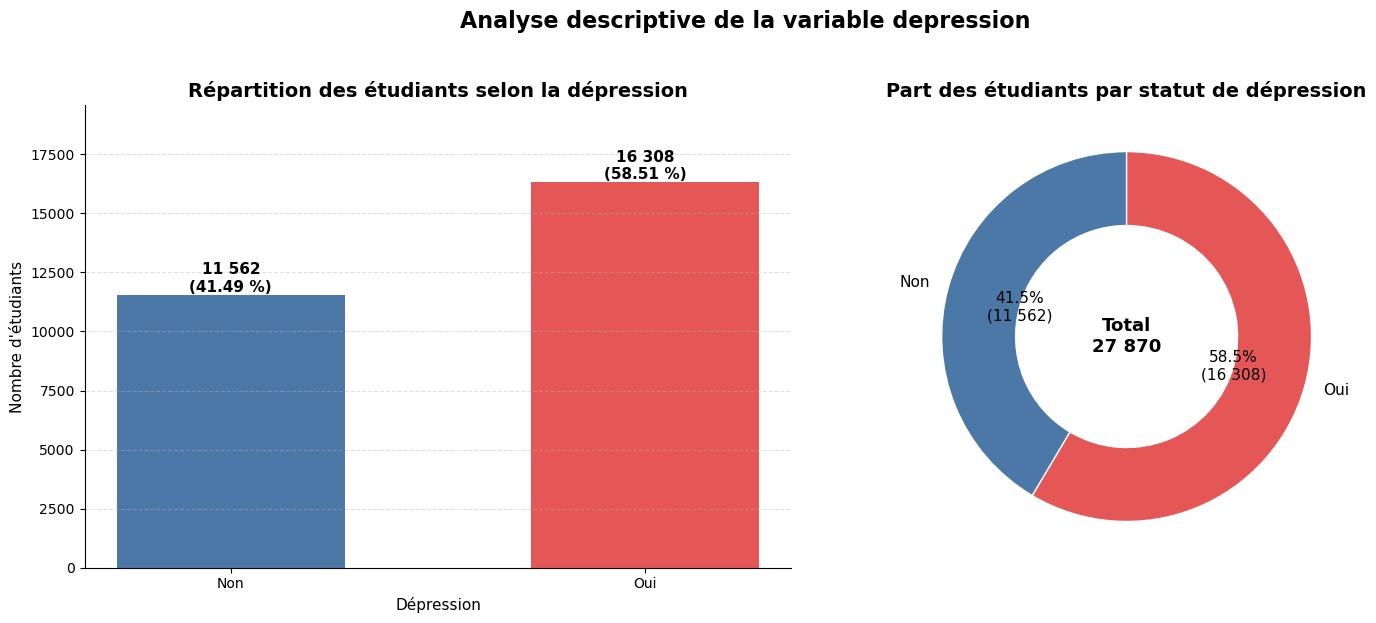

In [118]:
# Copie de la variable depression pour éviter de modifier directement le dataframe original
depression = df["depression"].astype(str).str.strip().str.lower()

# Harmonisation des modalités possibles
# Ce code fonctionne si la variable est codée en 0/1, Oui/Non ou Yes/No
depression = depression.replace({
    "0": "Non",
    "1": "Oui",
    "non": "Non",
    "oui": "Oui",
    "no": "Non",
    "yes": "Oui"
})

# Calcul des effectifs et des pourcentages
repartition_depression = (
    depression
    .value_counts()
    .rename_axis("Dépression")
    .reset_index(name="Nombre")
)

total_etudiants = repartition_depression["Nombre"].sum()

repartition_depression["Pourcentage"] = (
    repartition_depression["Nombre"] / total_etudiants * 100
).round(2)

# Ordre logique d'affichage : Non puis Oui
ordre = ["Non", "Oui"]
repartition_depression["Dépression"] = pd.Categorical(
    repartition_depression["Dépression"],
    categories=ordre,
    ordered=True
)

repartition_depression = repartition_depression.sort_values("Dépression")

# Affichage du tableau récapitulatif
display(repartition_depression)

# Création du graphique avancé
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

couleurs = ["#4C78A8", "#E45756"]

# -----------------------------
# Graphique 1 : barres verticales
# -----------------------------
bars = axes[0].bar(
    repartition_depression["Dépression"],
    repartition_depression["Nombre"],
    color=couleurs,
    width=0.55
)

axes[0].set_title(
    "Répartition des étudiants selon la dépression",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Dépression", fontsize=11)
axes[0].set_ylabel("Nombre d'étudiants", fontsize=11)

axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Suppression des bordures inutiles
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Ajout des étiquettes : nombre exact + pourcentage
for bar, nombre, pourcentage in zip(
    bars,
    repartition_depression["Nombre"],
    repartition_depression["Pourcentage"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{nombre:,}".replace(",", " ") + f"\n({pourcentage} %)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Augmenter légèrement la limite de l'axe Y pour laisser de l'espace aux étiquettes
axes[0].set_ylim(0, repartition_depression["Nombre"].max() * 1.20)

# -----------------------------
# Graphique 2 : diagramme en anneau
# -----------------------------
def format_pourcentage(pct):
    nombre = int(round(pct / 100 * total_etudiants))
    return f"{pct:.1f}%\n({nombre:,})".replace(",", " ")

wedges, texts, autotexts = axes[1].pie(
    repartition_depression["Nombre"],
    labels=repartition_depression["Dépression"],
    autopct=format_pourcentage,
    startangle=90,
    colors=couleurs,
    wedgeprops={"width": 0.40, "edgecolor": "white"},
    textprops={"fontsize": 11}
)

axes[1].set_title(
    "Part des étudiants par statut de dépression",
    fontsize=14,
    fontweight="bold"
)

# Texte central du diagramme en anneau
axes[1].text(
    0,
    0,
    f"Total\n{total_etudiants:,}".replace(",", " "),
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

# Titre global
fig.suptitle(
    "Analyse descriptive de la variable depression",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

<br>
<br>

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


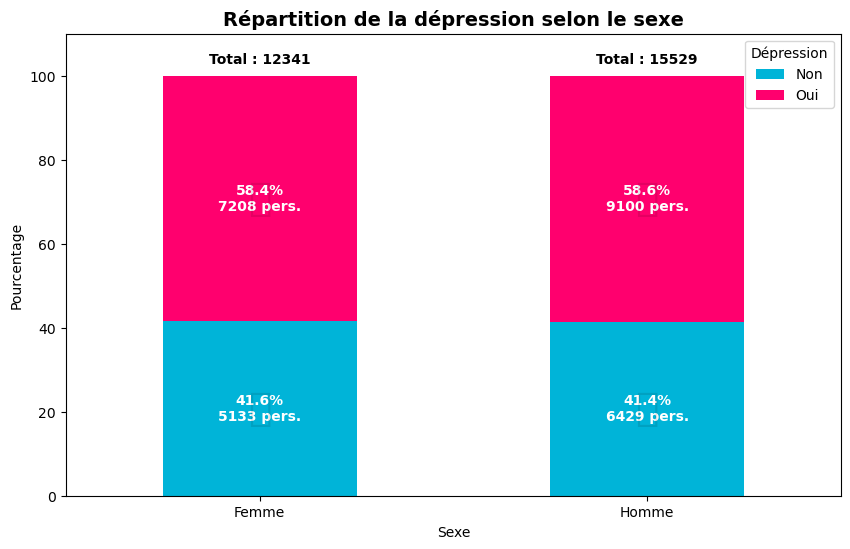

In [119]:
table_pct = pd.crosstab(
    df["sexe"],
    df["depression"],
    normalize="index"
).mul(100)

table_n = pd.crosstab(
    df["sexe"],
    df["depression"]
)

ax = table_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#00B4D8", "#FF006E"]
)

for container, col in zip(ax.containers, table_pct.columns):
    labels = [
        f"{pct:.1f}%\n{int(n)} pers."
        for pct, n in zip(table_pct[col], table_n[col])
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10,
        color="white",
        fontweight="bold"
    )

for patch in ax.patches:
    hauteur = patch.get_height()
    if hauteur > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_y() + hauteur / 2

        ax.text(
            x, y, "👤",
            ha="center",
            va="center",
            fontsize=28,
            color="black",
            alpha=0.10
        )

for i, total in enumerate(table_n.sum(axis=1)):
    ax.text(
        i, 103,
        f"Total : {total}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Répartition de la dépression selon le sexe", fontsize=14, fontweight="bold")
plt.xlabel("Sexe")
plt.ylabel("Pourcentage")
plt.legend(title="Dépression")
plt.xticks(rotation=0)
plt.ylim(0, 110)
plt.show()

<br>
<br>

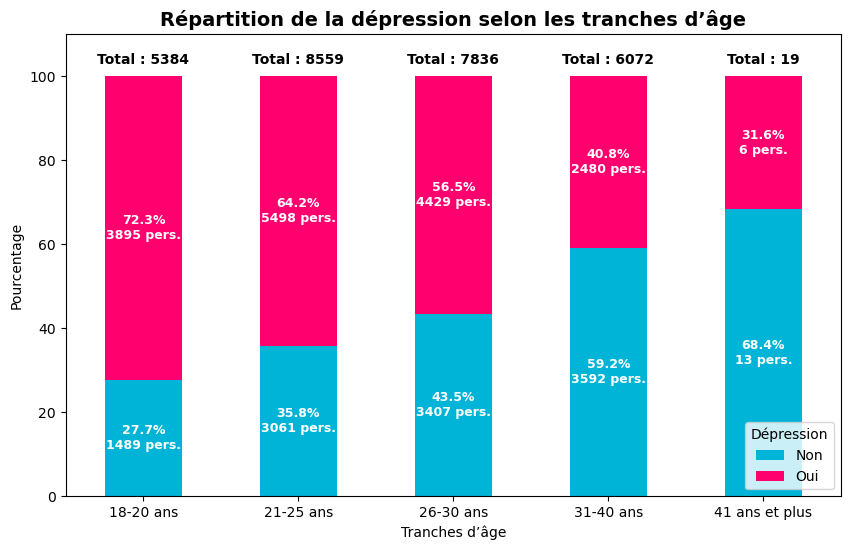

In [120]:
table_pct = pd.crosstab(
    df["tranche_age"],
    df["depression"],
    normalize="index"
).mul(100)

table_n = pd.crosstab(
    df["tranche_age"],
    df["depression"]
)

ax = table_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#00B4D8", "#FF006E"]
)

for container, col in zip(ax.containers, table_pct.columns):
    labels = [
        f"{pct:.1f}%\n{n} pers."
        for pct, n in zip(table_pct[col], table_n[col])
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

for i, total in enumerate(table_n.sum(axis=1)):
    ax.text(
        i, 103,
        f"Total : {total}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Répartition de la dépression selon les tranches d’âge", fontsize=14, fontweight="bold")
plt.xlabel("Tranches d’âge")
plt.ylabel("Pourcentage")
plt.legend(title="Dépression")
plt.xticks(rotation=0)
plt.ylim(0, 110)
plt.show()

<br>
<br>

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


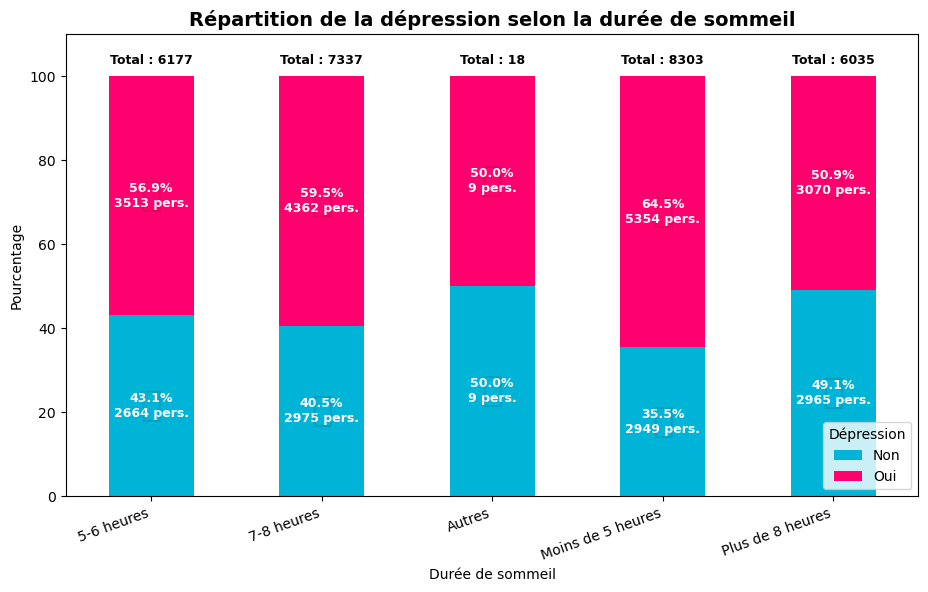

In [121]:
table_pct = pd.crosstab(
    df["duree_sommeil"],
    df["depression"],
    normalize="index"
).mul(100)

table_n = pd.crosstab(
    df["duree_sommeil"],
    df["depression"]
)

ax = table_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=["#00B4D8", "#FF006E"]
)

for container, col in zip(ax.containers, table_pct.columns):
    labels = [
        f"{pct:.1f}%\n{int(n)} pers."
        for pct, n in zip(table_pct[col], table_n[col])
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

for patch in ax.patches:
    hauteur = patch.get_height()
    if hauteur > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_y() + hauteur / 2

        ax.text(
            x, y, "👤",
            ha="center",
            va="center",
            fontsize=26,
            color="black",
            alpha=0.10
        )

for i, total in enumerate(table_n.sum(axis=1)):
    ax.text(
        i, 103,
        f"Total : {total}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Répartition de la dépression selon la durée de sommeil", fontsize=14, fontweight="bold")
plt.xlabel("Durée de sommeil")
plt.ylabel("Pourcentage")
plt.legend(title="Dépression")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 110)
plt.show()

<br>
<br>

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


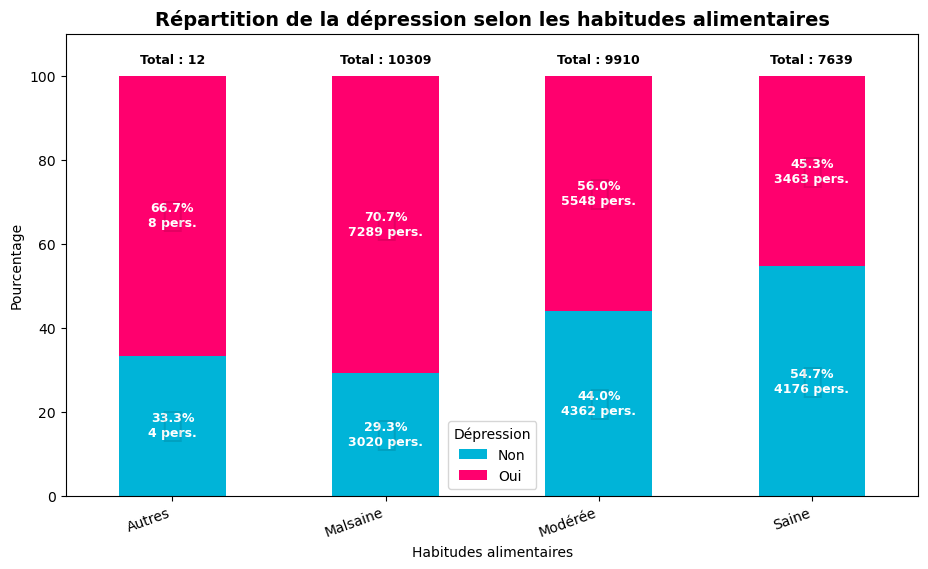

In [122]:
table_pct = pd.crosstab(
    df["habitudes_alimentaires"],
    df["depression"],
    normalize="index"
).mul(100)

table_n = pd.crosstab(
    df["habitudes_alimentaires"],
    df["depression"]
)

ax = table_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=["#00B4D8", "#FF006E"]
)

for container, col in zip(ax.containers, table_pct.columns):
    labels = [
        f"{pct:.1f}%\n{int(n)} pers."
        for pct, n in zip(table_pct[col], table_n[col])
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

for patch in ax.patches:
    hauteur = patch.get_height()
    if hauteur > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_y() + hauteur / 2

        ax.text(
            x, y, "👤",
            ha="center",
            va="center",
            fontsize=26,
            color="black",
            alpha=0.10
        )

for i, total in enumerate(table_n.sum(axis=1)):
    ax.text(
        i, 103,
        f"Total : {total}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Répartition de la dépression selon les habitudes alimentaires", fontsize=14, fontweight="bold")
plt.xlabel("Habitudes alimentaires")
plt.ylabel("Pourcentage")
plt.legend(title="Dépression")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 110)
plt.show()

<br>
<br>

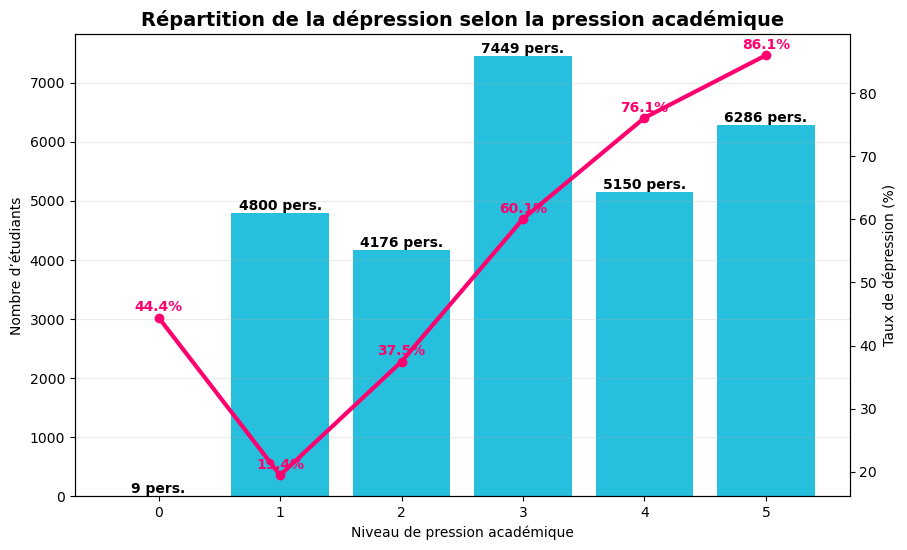

In [123]:
stats_pression = df.groupby("pression_academique").agg(
    effectif=("depression_num", "count"),
    taux_depression=("depression_num", "mean")
).reset_index()

stats_pression["taux_depression"] *= 100

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(
    stats_pression["pression_academique"],
    stats_pression["effectif"],
    color="#00B4D8",
    alpha=0.85
)

for i, row in stats_pression.iterrows():
    ax1.text(
        row["pression_academique"],
        row["effectif"] + 50,
        f'{int(row["effectif"])} pers.',
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax2 = ax1.twinx()

ax2.plot(
    stats_pression["pression_academique"],
    stats_pression["taux_depression"],
    marker="o",
    linewidth=3,
    color="#FF006E"
)

for i, row in stats_pression.iterrows():
    ax2.text(
        row["pression_academique"],
        row["taux_depression"] + 1,
        f'{row["taux_depression"]:.1f}%',
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#FF006E"
    )

ax1.set_title("Répartition de la dépression selon la pression académique", fontsize=14, fontweight="bold")
ax1.set_xlabel("Niveau de pression académique")
ax1.set_ylabel("Nombre d’étudiants")
ax2.set_ylabel("Taux de dépression (%)")

ax1.grid(axis="y", alpha=0.25)
plt.show()

<br>
<br>

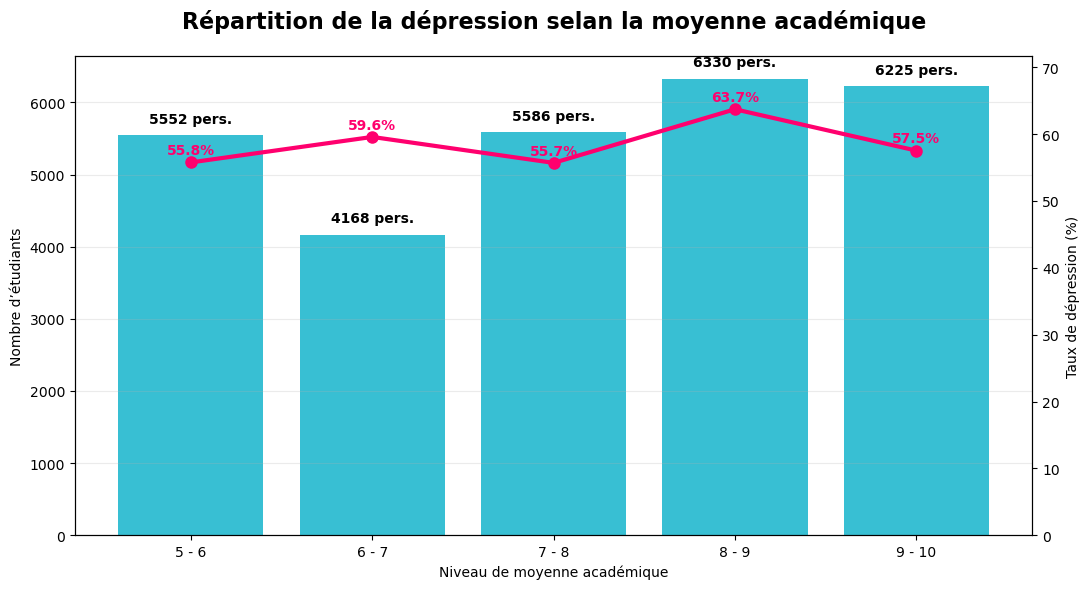

In [124]:
# Regrouper la moyenne académique en classes
df["classe_moyenne_academique"] = pd.cut(
    df["moyenne_academique"],
    bins=[0, 5, 6, 7, 8, 9, 10],
    labels=["≤ 5", "5 - 6", "6 - 7", "7 - 8", "8 - 9", "9 - 10"],
    include_lowest=True
)

# Calcul des statistiques
stats_moyenne = df.groupby("classe_moyenne_academique", observed=False).agg(
    effectif=("depression_num", "count"),
    taux_depression=("depression_num", "mean")
).reset_index()

stats_moyenne["taux_depression"] *= 100

# Supprimer les classes avec trop peu d'observations
min_effectif = 30
stats_moyenne = stats_moyenne[stats_moyenne["effectif"] >= min_effectif]

# Graphique
fig, ax1 = plt.subplots(figsize=(11, 6))

bars = ax1.bar(
    stats_moyenne["classe_moyenne_academique"].astype(str),
    stats_moyenne["effectif"],
    color="#22B8CF",
    alpha=0.9
)

# Étiquettes des effectifs
for bar, val in zip(bars, stats_moyenne["effectif"]):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + stats_moyenne["effectif"].max()*0.02,
        f"{int(val)} pers.",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax1.set_ylabel("Nombre d’étudiants")

# Deuxième axe : taux de dépression
ax2 = ax1.twinx()
ax2.plot(
    stats_moyenne["classe_moyenne_academique"].astype(str),
    stats_moyenne["taux_depression"],
    color="#FF006E",
    marker="o",
    linewidth=3,
    markersize=8
)

# Étiquettes des pourcentages
for x, y in zip(stats_moyenne["classe_moyenne_academique"].astype(str), stats_moyenne["taux_depression"]):
    ax2.text(
        x, y + 0.8,
        f"{y:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#FF006E"
    )

ax2.set_ylabel("Taux de dépression (%)")
ax2.set_ylim(0, stats_moyenne["taux_depression"].max() + 8)

plt.title("Répartition de la dépression selan la moyenne académique", fontsize=16, fontweight="bold", pad=20)
ax1.set_xlabel("Niveau de moyenne académique")
ax1.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

<br>
<br>

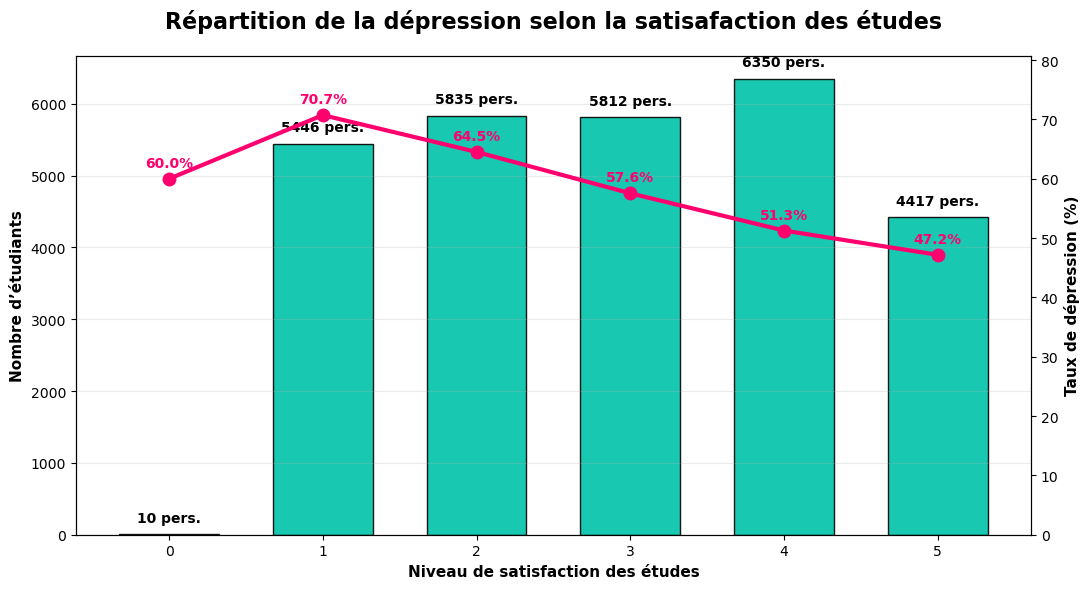

In [125]:
stats_satisfaction = (
    df.groupby("satisfaction_etudes", observed=False)
      .agg(
          effectif=("depression_num", "count"),
          taux_depression=("depression_num", "mean")
      )
      .reset_index()
      .sort_values("satisfaction_etudes")
)

stats_satisfaction["taux_depression"] *= 100

fig, ax1 = plt.subplots(figsize=(11, 6))

# Barres : effectifs
bars = ax1.bar(
    stats_satisfaction["satisfaction_etudes"].astype(str),
    stats_satisfaction["effectif"],
    color="#00C2A8",
    alpha=0.9,
    width=0.65,
    edgecolor="black",
    linewidth=1
)

for bar, val in zip(bars, stats_satisfaction["effectif"]):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + stats_satisfaction["effectif"].max()*0.02,
        f"{int(val)} pers.",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax1.set_ylabel("Nombre d’étudiants", fontsize=11, fontweight="bold")
ax1.set_xlabel("Niveau de satisfaction des études", fontsize=11, fontweight="bold")
ax1.grid(axis="y", alpha=0.25)

# Courbe : taux de dépression
ax2 = ax1.twinx()
ax2.plot(
    stats_satisfaction["satisfaction_etudes"].astype(str),
    stats_satisfaction["taux_depression"],
    color="#FF006E",
    marker="o",
    markersize=9,
    linewidth=3
)

for x, y in zip(stats_satisfaction["satisfaction_etudes"].astype(str),
                stats_satisfaction["taux_depression"]):
    ax2.text(
        x, y + 1.5,
        f"{y:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#FF006E"
    )

ax2.set_ylabel("Taux de dépression (%)", fontsize=11, fontweight="bold")
ax2.set_ylim(0, stats_satisfaction["taux_depression"].max() + 10)

plt.title(
    "Répartition de la dépression selon la satisafaction des études",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

<br>
<br>

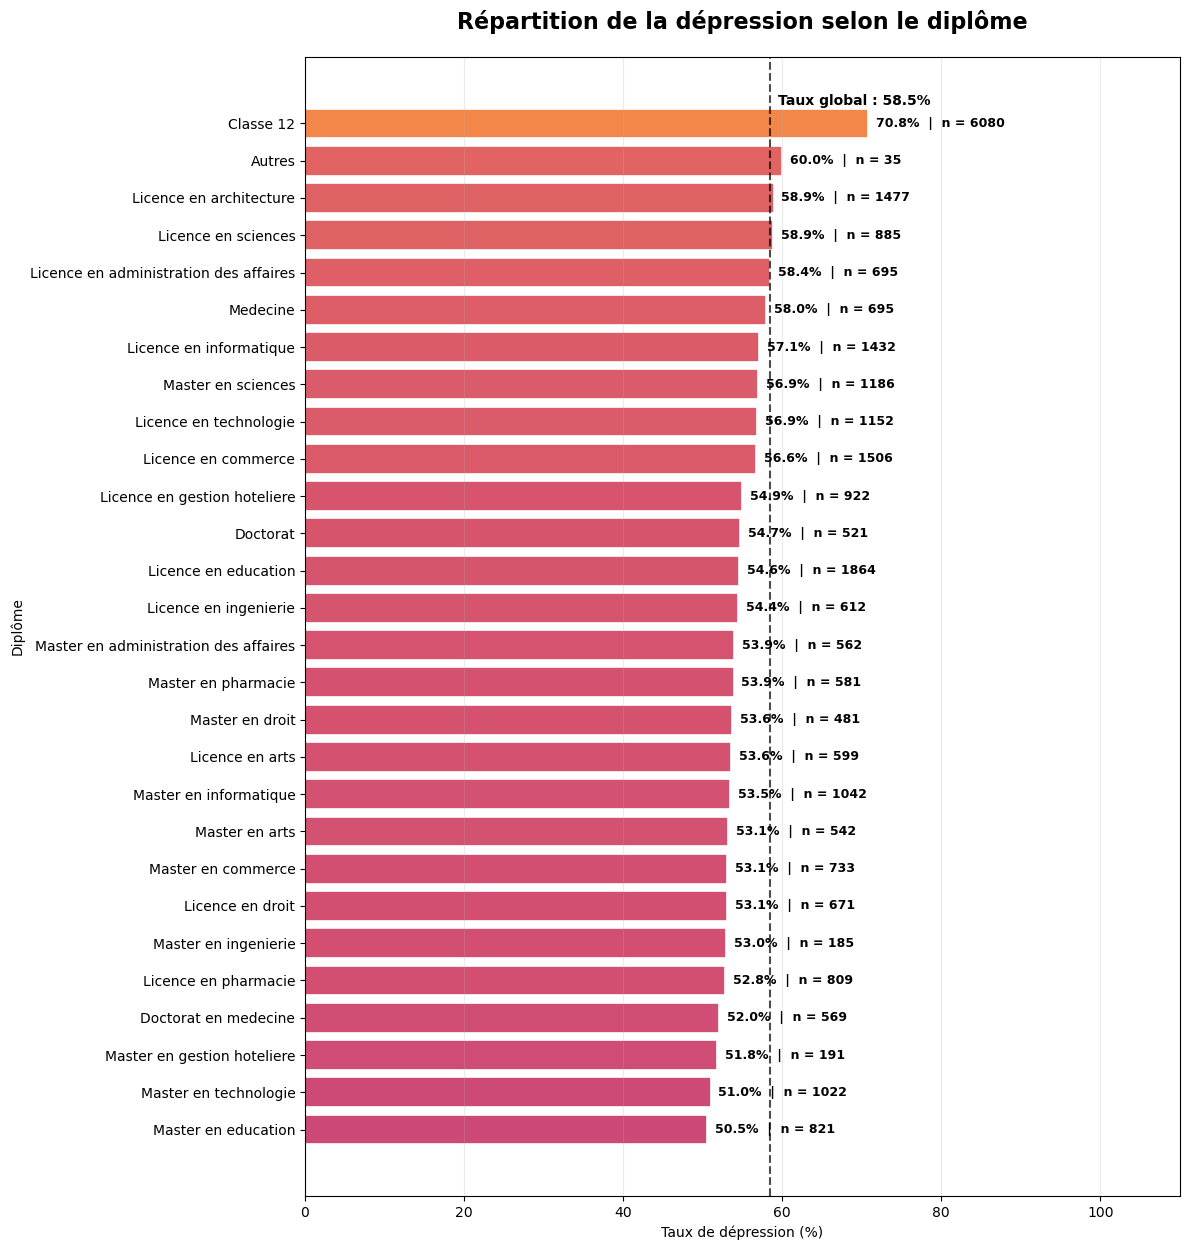

In [126]:
min_effectif = 1

stats_diplome = (
    df.groupby("diplome", observed=False)
      .agg(
          effectif=("depression_num", "count"),
          nb_depression=("depression_num", "sum"),
          taux_depression=("depression_num", "mean")
      )
      .reset_index()
)

stats_diplome["taux_depression"] = (stats_diplome["taux_depression"] * 100).round(2)

stats_diplome = (
    stats_diplome[stats_diplome["effectif"] >= min_effectif]
    .sort_values("taux_depression")
)

taux_global = df["depression_num"].mean() * 100

fig, ax = plt.subplots(figsize=(12, max(7, len(stats_diplome) * 0.45)))

couleurs = plt.cm.plasma(stats_diplome["taux_depression"] / 100)

bars = ax.barh(
    stats_diplome["diplome"].astype(str),
    stats_diplome["taux_depression"],
    color=couleurs,
    edgecolor="white",
    linewidth=1.2
)

for bar, taux, effectif in zip(
    bars,
    stats_diplome["taux_depression"],
    stats_diplome["effectif"]
):
    ax.text(
        taux + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{taux:.1f}%  |  n = {int(effectif)}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.axvline(
    taux_global,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

ax.text(
    taux_global + 1,
    len(stats_diplome) - 0.5,
    f"Taux global : {taux_global:.1f}%",
    fontsize=10,
    fontweight="bold",
    color="black"
)

ax.set_title(
    "Répartition de la dépression selon le diplôme",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Taux de dépression (%)")
ax.set_ylabel("Diplôme")
ax.set_xlim(0, 110)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

<br>
<br>

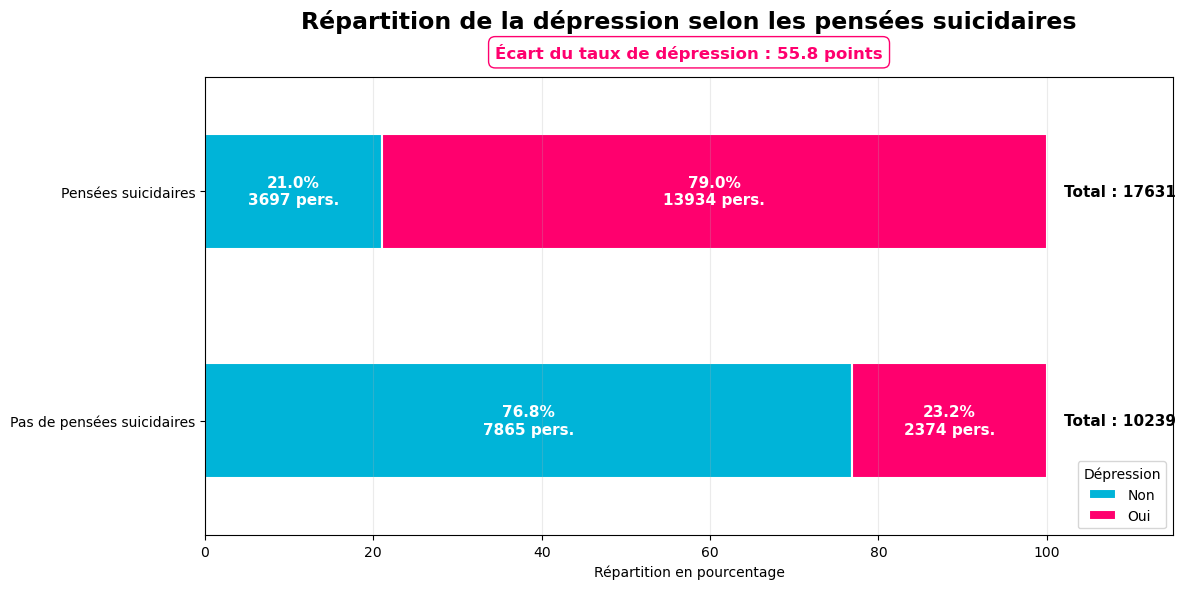

In [127]:
table_n = pd.crosstab(
    df["pensees_suicidaires"],
    df["depression"]
).reindex(columns=["Non", "Oui"])

table_pct = table_n.div(table_n.sum(axis=1), axis=0).mul(100)

labels_index = {
    "Non": "Pas de pensées suicidaires",
    "Oui": "Pensées suicidaires"
}

table_n = table_n.rename(index=labels_index)
table_pct = table_pct.rename(index=labels_index)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#00B4D8", "#FF006E"]

table_pct.plot(
    kind="barh",
    stacked=True,
    color=colors,
    ax=ax,
    edgecolor="white",
    linewidth=1.5
)

for container, col in zip(ax.containers, table_pct.columns):
    labels = [
        f"{pct:.1f}%\n{int(n)} pers."
        for pct, n in zip(table_pct[col], table_n[col])
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=11,
        color="white",
        fontweight="bold"
    )

for i, total in enumerate(table_n.sum(axis=1)):
    ax.text(
        102,
        i,
        f"Total : {int(total)}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

taux_depression = table_pct["Oui"]
ecart = taux_depression.max() - taux_depression.min()

ax.text(
    0.5,
    1.04,
    f"Écart du taux de dépression : {ecart:.1f} points",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    fontweight="bold",
    color="#FF006E",
    bbox=dict(facecolor="white", edgecolor="#FF006E", boxstyle="round,pad=0.4")
)

ax.set_title(
    "Répartition de la dépression selon les pensées suicidaires",
    fontsize=17,
    fontweight="bold",
    pad=35
)

ax.set_xlabel("Répartition en pourcentage")
ax.set_ylabel("")
ax.set_xlim(0, 115)

ax.legend(
    title="Dépression",
    loc="lower right"
)

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

<br>
<br>

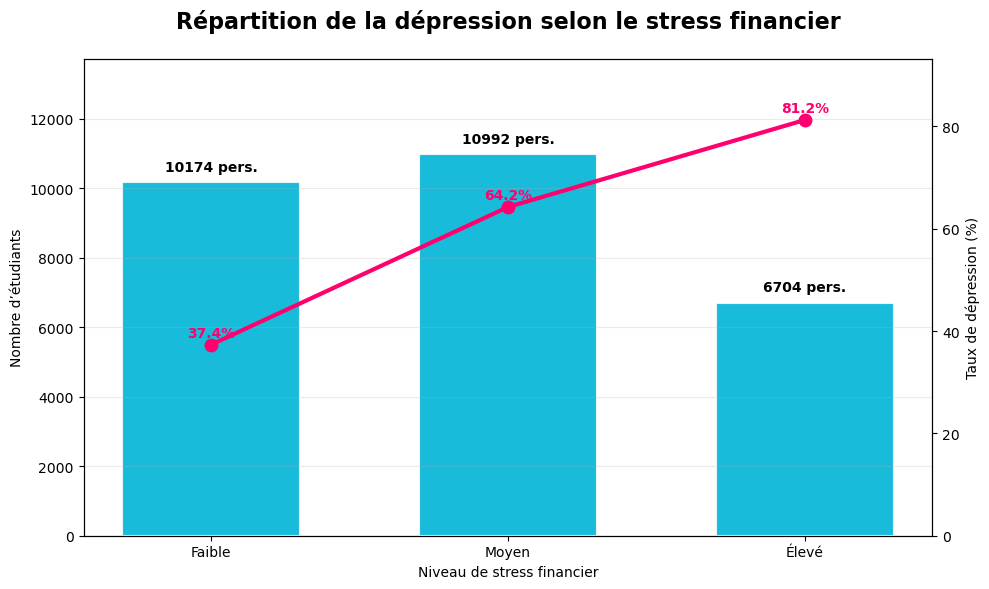

In [128]:
stats_stress = (
    df.groupby("niveau_stress_financier", observed=False)
      .agg(
          effectif=("depression_num", "count"),
          taux_depression=("depression_num", "mean")
      )
      .reset_index()
)

stats_stress["taux_depression"] *= 100

fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(
    stats_stress["niveau_stress_financier"].astype(str),
    stats_stress["effectif"],
    color="#00B4D8",
    alpha=0.9,
    width=0.6,
    edgecolor="white",
    linewidth=1.5
)

for bar, effectif in zip(bars, stats_stress["effectif"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + stats_stress["effectif"].max() * 0.03,
        f"{int(effectif)} pers.",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax2 = ax1.twinx()

ax2.plot(
    stats_stress["niveau_stress_financier"].astype(str),
    stats_stress["taux_depression"],
    color="#FF006E",
    marker="o",
    markersize=9,
    linewidth=3
)

for x, y in zip(
    stats_stress["niveau_stress_financier"].astype(str),
    stats_stress["taux_depression"]
):
    ax2.text(
        x,
        y + 1.5,
        f"{y:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#FF006E"
    )

ax1.set_title(
    "Répartition de la dépression selon le stress financier",
    fontsize=16,
    fontweight="bold",
    pad=22
)

ax1.set_xlabel("Niveau de stress financier")
ax1.set_ylabel("Nombre d’étudiants")
ax2.set_ylabel("Taux de dépression (%)")

ax1.set_ylim(0, stats_stress["effectif"].max() * 1.25)
ax2.set_ylim(0, stats_stress["taux_depression"].max() + 12)

ax1.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

<br>
<br>

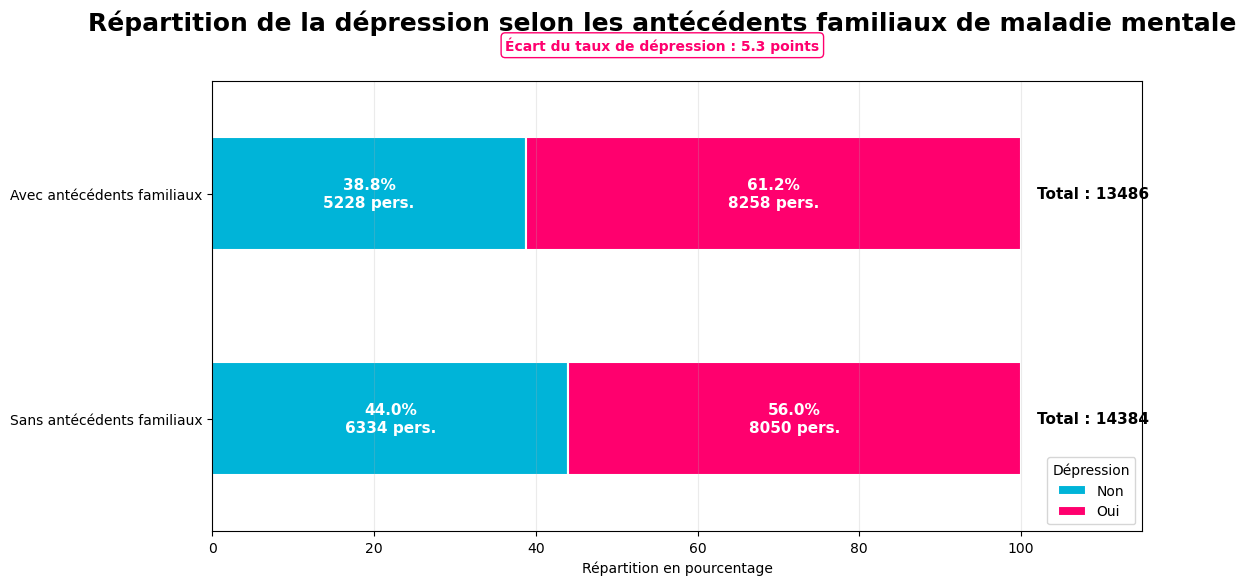

In [129]:
table_n = pd.crosstab(
    df["antecedents_familiaux_maladie_mentale"],
    df["depression"]
).reindex(columns=["Non", "Oui"])

table_pct = table_n.div(table_n.sum(axis=1), axis=0).mul(100)

labels_index = {
    "No": "Sans antécédents familiaux",
    "Yes": "Avec antécédents familiaux",
    "Non": "Sans antécédents familiaux",
    "Oui": "Avec antécédents familiaux"
}

table_n = table_n.rename(index=labels_index)
table_pct = table_pct.rename(index=labels_index)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#00B4D8", "#FF006E"]

table_pct.plot(
    kind="barh",
    stacked=True,
    color=colors,
    ax=ax,
    edgecolor="white",
    linewidth=1.5
)

# Pourcentages + effectifs
for container, col in zip(ax.containers, table_pct.columns):
    labels = [
        f"{pct:.1f}%\n{int(n)} pers."
        for pct, n in zip(table_pct[col], table_n[col])
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=11,
        color="white",
        fontweight="bold"
    )

# Totaux à droite
for i, total in enumerate(table_n.sum(axis=1)):
    ax.text(
        102,
        i,
        f"Total : {int(total)}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Calcul de l'écart
taux_depression = table_pct["Oui"]
ecart = taux_depression.max() - taux_depression.min()

# Titre principal
fig.suptitle(
    "Répartition de la dépression selon les antécédents familiaux de maladie mentale",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

# Encadré bien placé sous le titre
fig.text(
    0.5, 0.92,
    f"Écart du taux de dépression : {ecart:.1f} points",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color="#FF006E",
    bbox=dict(facecolor="white", edgecolor="#FF006E", boxstyle="round,pad=0.3")
)

ax.set_xlabel("Répartition en pourcentage")
ax.set_ylabel("")
ax.set_xlim(0, 115)
ax.legend(title="Dépression", loc="lower right")
ax.grid(axis="x", alpha=0.25)

# Espace en haut pour éviter tout chevauchement
plt.subplots_adjust(top=0.86)

plt.show()

In [130]:
variables_croisees = [
    "pensees_suicidaires",
    "niveau_stress_financier",
    "niveau_pression_academique"
]

analyse_3_variables = (
    df.groupby(variables_croisees, observed=False)
      .agg(
          effectif=("depression_num", "count"),
          nb_depression=("depression_num", "sum"),
          taux_depression=("depression_num", "mean")
      )
      .reset_index()
)

analyse_3_variables["taux_depression"] = (
    analyse_3_variables["taux_depression"] * 100
).round(2)

# On garde seulement les groupes avec un effectif suffisant
analyse_3_variables = analyse_3_variables[analyse_3_variables["effectif"] >= 30]

analyse_3_variables.sort_values(
    by="taux_depression",
    ascending=False
).head(15)

,pensees_suicidaires,niveau_stress_financier,niveau_pression_academique,effectif,nb_depression,taux_depression
17,Oui,Élevé,Élevée,1582,1556,98.36
14,Oui,Moyen,Élevée,2012,1917,95.28
16,Oui,Élevé,Moyenne,2514,2353,93.60
11,Oui,Faible,Élevée,1239,1095,88.38
13,Oui,Moyen,Moyenne,3679,3217,87.44
8,Non,Élevé,Élevée,334,272,81.44
15,Oui,Élevé,Faible,980,751,76.63
10,Oui,Faible,Moyenne,2473,1702,68.82
5,Non,Moyen,Élevée,558,354,63.44
7,Non,Élevé,Moyenne,666,377,56.61


In [131]:
def graphique_croise_simple(df, x, groupe, titre, ordre_x=None, ordre_groupe=None, min_effectif=30):
    stats = (
        df.groupby([x, groupe], observed=False)
          .agg(
              effectif=("depression_num", "count"),
              taux_depression=("depression_num", "mean")
          )
          .reset_index()
    )

    stats["taux_depression"] *= 100

    stats["_x"] = stats[x].astype(str)
    stats["_groupe"] = stats[groupe].astype(str)

    if ordre_x is None:
        ordre_x = stats["_x"].dropna().unique().tolist()
    else:
        ordre_x = [str(v) for v in ordre_x]

    if ordre_groupe is None:
        ordre_groupe = stats["_groupe"].dropna().unique().tolist()
    else:
        ordre_groupe = [str(v) for v in ordre_groupe]

    pivot_taux = stats.pivot(index="_x", columns="_groupe", values="taux_depression").reindex(
        index=ordre_x, columns=ordre_groupe
    )

    pivot_n = stats.pivot(index="_x", columns="_groupe", values="effectif").reindex(
        index=ordre_x, columns=ordre_groupe
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    x_pos = np.arange(len(ordre_x))
    largeur = 0.75 / len(ordre_groupe)

    couleurs = ["#00B4D8", "#FF006E", "#FFBE0B", "#8338EC", "#06D6A0"]

    for i, modalite in enumerate(ordre_groupe):
        valeurs = pivot_taux[modalite].values
        effectifs = pivot_n[modalite].values

        position = x_pos + (i - (len(ordre_groupe) - 1) / 2) * largeur

        bars = ax.bar(
            position,
            valeurs,
            width=largeur,
            label=modalite,
            color=couleurs[i % len(couleurs)],
            edgecolor="white",
            linewidth=1.2
        )

        for bar, taux, n in zip(bars, valeurs, effectifs):
            if pd.notna(taux):
                texte = f"{taux:.1f}%\nn={int(n)}"

                if n < min_effectif:
                    texte += "\nfaible n"

                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1,
                    texte,
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight="bold"
                )

    ax.set_title(titre, fontsize=15, fontweight="bold", pad=20)
    ax.set_xlabel(x)
    ax.set_ylabel("Taux de dépression (%)")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ordre_x, rotation=0)
    ax.set_ylim(0, 100)
    ax.legend(title=groupe)
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

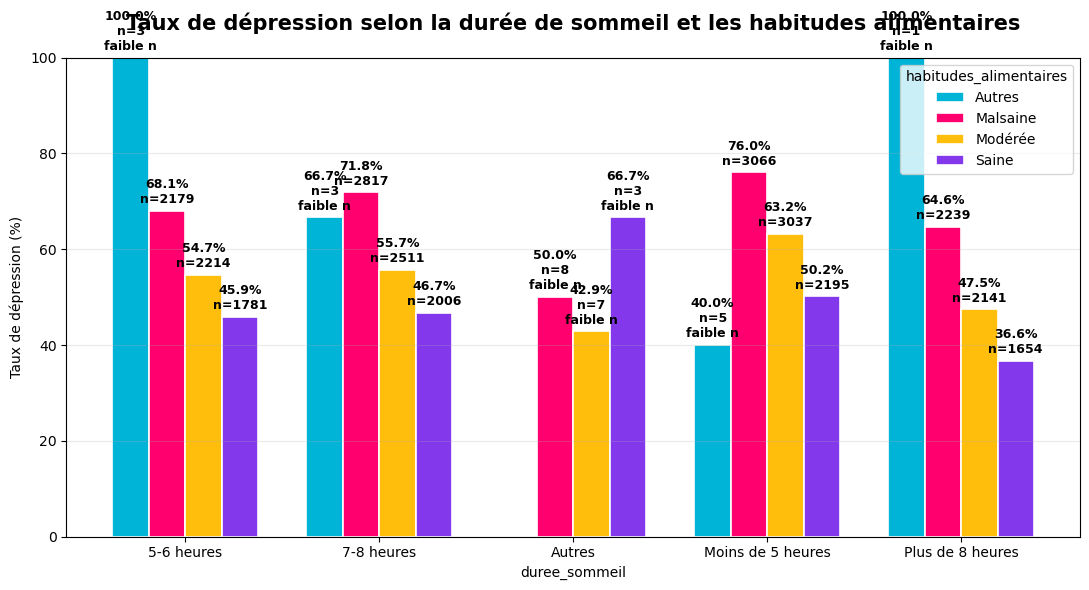

In [132]:
graphique_croise_simple(
    df,
    x="duree_sommeil",
    groupe="habitudes_alimentaires",
    titre="Taux de dépression selon la durée de sommeil et les habitudes alimentaires"
)

In [133]:
df["pensees_suicidaires_clair"] = df["pensees_suicidaires"].astype(str).replace({
    "Yes": "Pensées suicidaires",
    "No": "Pas de pensées suicidaires",
    "Oui": "Pensées suicidaires",
    "Non": "Pas de pensées suicidaires"
})

df["antecedents_familiaux_clair"] = df["antecedents_familiaux_maladie_mentale"].astype(str).replace({
    "Yes": "Avec antécédents",
    "No": "Sans antécédents",
    "Oui": "Avec antécédents",
    "Non": "Sans antécédents"
})

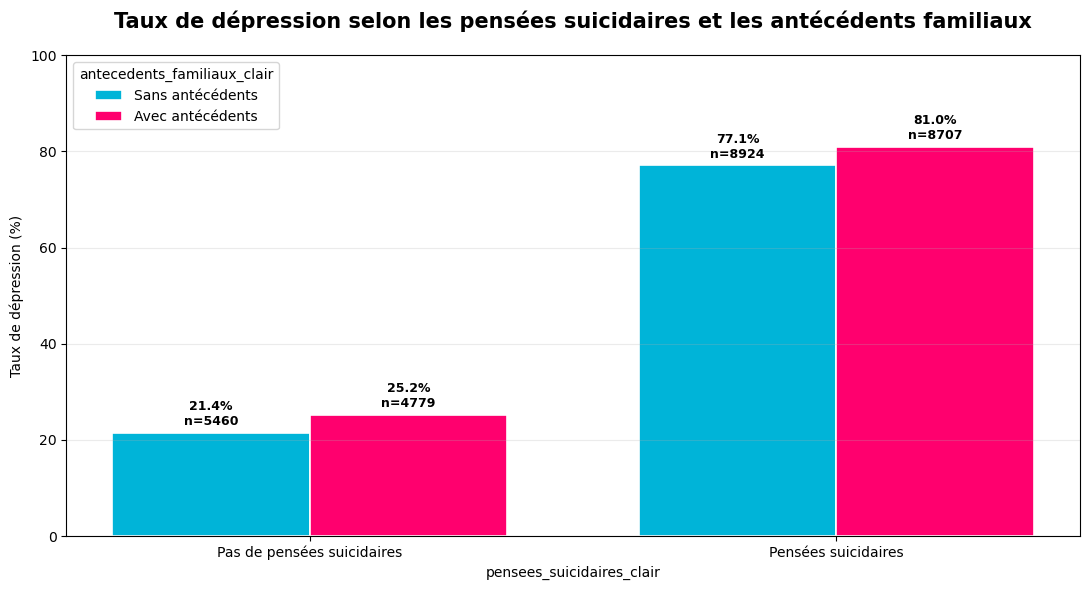

In [134]:
graphique_croise_simple(
    df,
    x="pensees_suicidaires_clair",
    groupe="antecedents_familiaux_clair",
    titre="Taux de dépression selon les pensées suicidaires et les antécédents familiaux",
    ordre_x=["Pas de pensées suicidaires", "Pensées suicidaires"],
    ordre_groupe=["Sans antécédents", "Avec antécédents"]
)

<div style="background-color:#F8F9FA; border:2px solid #343A40; padding:14px; border-radius:8px; margin-top:22px; margin-bottom:18px;">

<h2 style="color:#343A40; font-family:'Segoe UI', Arial, sans-serif; text-align:center;">
Export pour Excel Power Piwot
</h2>

</div>

In [135]:
df.head()

,id,sexe,age,ville,profession,pression_academique,moyenne_academique,satisfaction_etudes,duree_sommeil,habitudes_alimentaires,diplome,pensees_suicidaires,heures_travail_etudes,stress_financier,antecedents_familiaux_maladie_mentale,depression,depression_num,tranche_age,niveau_pression_academique,niveau_satisfaction_etudes,niveau_stress_financier,classe_moyenne_academique,pensees_suicidaires_clair,antecedents_familiaux_clair
0,2,Homme,33,Visakhapatnam,Etudiant,5,8.97,2,5-6 heures,Saine,Licence en pharmacie,Oui,3,1,Non,Oui,1,31-40 ans,Élevée,Faible,Faible,8 - 9,Pensées suicidaires,Sans antécédents
1,8,Femme,24,Bangalore,Etudiant,2,5.90,5,5-6 heures,Modérée,Licence en sciences,Non,3,2,Oui,Non,0,21-25 ans,Faible,Élevée,Faible,5 - 6,Pas de pensées suicidaires,Avec antécédents
2,26,Homme,31,Srinagar,Etudiant,3,7.03,5,Moins de 5 heures,Saine,Licence en arts,Non,9,1,Oui,Non,0,31-40 ans,Moyenne,Élevée,Faible,7 - 8,Pas de pensées suicidaires,Avec antécédents
3,30,Femme,28,Varanasi,Etudiant,3,5.59,2,7-8 heures,Modérée,Licence en informatique,Oui,4,5,Oui,Oui,1,26-30 ans,Moyenne,Faible,Élevé,5 - 6,Pensées suicidaires,Avec antécédents
4,32,Femme,25,Jaipur,Etudiant,4,8.13,3,5-6 heures,Modérée,Master en technologie,Oui,1,1,Non,Non,0,21-25 ans,Moyenne,Moyenne,Faible,8 - 9,Pensées suicidaires,Sans antécédents


<br>
<br>

In [136]:
df_export = df.copy()

In [137]:
# Création correcte de depression_num à partir de Oui / Non

df_export["depression_num"] = (
    df_export["depression"]
    .astype(str)
    .str.strip()
    .map({
        "Oui": 1,
        "Non": 0,
        "Yes": 1,
        "No": 0,
        "1": 1,
        "0": 0
    })
)

# Création correcte du statut de dépression

df_export["statut_depression"] = df_export["depression_num"].map({
    0: "Sans dépression",
    1: "Avec dépression"
})

# Vérification
df_export[["depression", "depression_num", "statut_depression"]].drop_duplicates()

,depression,depression_num,statut_depression
0,Oui,1,Avec dépression
1,Non,0,Sans dépression


<br>
<br>

In [138]:
df_export["score_risque"] = (
    (df_export["pression_academique"] >= 4).astype(int)
    + (df_export["stress_financier"] >= 4).astype(int)
    + (df_export["satisfaction_etudes"] <= 2).astype(int)
    + (df_export["duree_sommeil"] == "Moins de 5 heures").astype(int)
    + (df_export["habitudes_alimentaires"] == "Malsaines").astype(int)
    + (df_export["pensees_suicidaires"] == "Oui").astype(int)
    + (df_export["antecedents_familiaux_maladie_mentale"] == "Oui").astype(int)
    + (df_export["heures_travail_etudes"] >= 8).astype(int))

<br>
<br>

In [139]:
df_export.to_excel(
    "student_depression_powerpivot.xlsx",
    index=False,
    sheet_name="donnees_nettoyees"
)

print("Fichier prêt pour Power Pivot")

Fichier prêt pour Power Pivot
